In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

test_path ="/content/KDDTest+.txt"
train_path = '/content/KDDTrain+.txt'

import csv
test_output = "KDDTest+.csv"
train_output = "KDDTrain+.csv"

# Function to convert TXT to CSV
def convert_txt_to_csv(input_path, output_path):
    with open(input_path, "r") as txt_file:
        with open(output_path, "w", newline="") as csv_file:
            writer = csv.writer(csv_file)
            for line in txt_file:
                row = line.strip().split(",")  # Split by commas
                writer.writerow(row)
    print(f"Converted {input_path} to {output_path}")

# Convert both files
convert_txt_to_csv(test_path, test_output)
convert_txt_to_csv(train_path, train_output)

df_test = pd.read_csv(test_output)
df_train = pd.read_csv(train_output)

Converted /content/KDDTest+.txt to KDDTest+.csv
Converted /content/KDDTrain+.txt to KDDTrain+.csv


In [ ]:
df_test.head()

,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21


In [ ]:
df_train.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])

df_test.columns = columns
df_train.columns = columns


In [ ]:
df_test['attack'].unique()

array(['neptune', 'normal', 'saint', 'mscan', 'guess_passwd', 'smurf',
       'apache2', 'satan', 'buffer_overflow', 'back', 'warezmaster',
       'snmpgetattack', 'processtable', 'pod', 'httptunnel', 'nmap', 'ps',
       'snmpguess', 'ipsweep', 'mailbomb', 'portsweep', 'multihop',
       'named', 'sendmail', 'loadmodule', 'xterm', 'worm', 'teardrop',
       'rootkit', 'xlock', 'perl', 'land', 'xsnoop', 'sqlattack',
       'ftp_write', 'imap', 'udpstorm', 'phf'], dtype=object)

In [ ]:
def change_label(df):
  df.attack.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],'Dos',inplace=True)
  df.attack.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'],'R2L',inplace=True)
  df.attack.replace(['ipsweep','mscan','nmap','portsweep','saint','satan'],'Probe',inplace=True)
  df.attack.replace(['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],'U2R',inplace=True)

In [ ]:
change_label(df_test)
change_label(df_train)

<ipython-input-10-63f8e6392d83>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.attack.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],'Dos',inplace=True)


In [ ]:
print(df_test.shape)
print(df_train.shape)


(22543, 43)
(125972, 43)


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22543 entries, 0 to 22542
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22543 non-null  int64  
 1   protocol_type                22543 non-null  object 
 2   service                      22543 non-null  object 
 3   flag                         22543 non-null  object 
 4   src_bytes                    22543 non-null  int64  
 5   dst_bytes                    22543 non-null  int64  
 6   land                         22543 non-null  int64  
 7   wrong_fragment               22543 non-null  int64  
 8   urgent                       22543 non-null  int64  
 9   hot                          22543 non-null  int64  
 10  num_failed_logins            22543 non-null  int64  
 11  logged_in                    22543 non-null  int64  
 12  num_compromised              22543 non-null  int64  
 13  root_shell      

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [ ]:
print(df_test.duplicated().sum())
print(df_train.duplicated().sum())


3
9


In [ ]:
df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)

In [ ]:
print(df_test.duplicated().sum())
print(df_train.duplicated().sum())


0
0


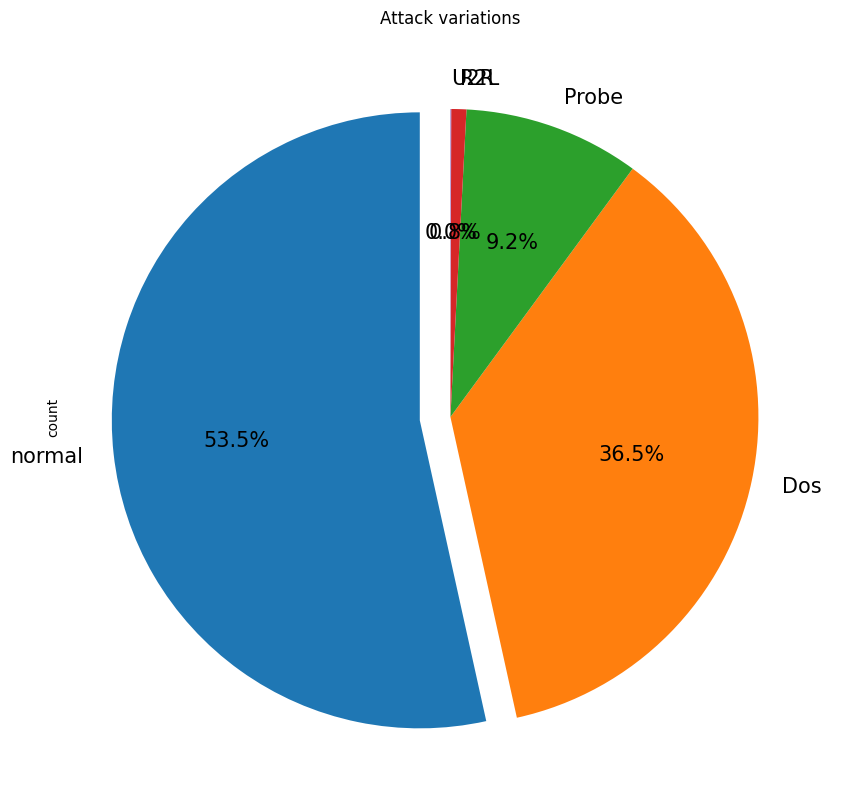

In [ ]:
data = df_train
plt.figure(figsize = (10,10))
explode = tuple([0.1] + [0]*(len(data['attack'].unique())-1)) # set the first slice to explode
data['attack'].value_counts().plot(kind='pie', explode=explode, startangle=90, autopct='%1.1f%%', fontsize=15)
plt.title('Attack variations')
plt.show()

<Axes: >

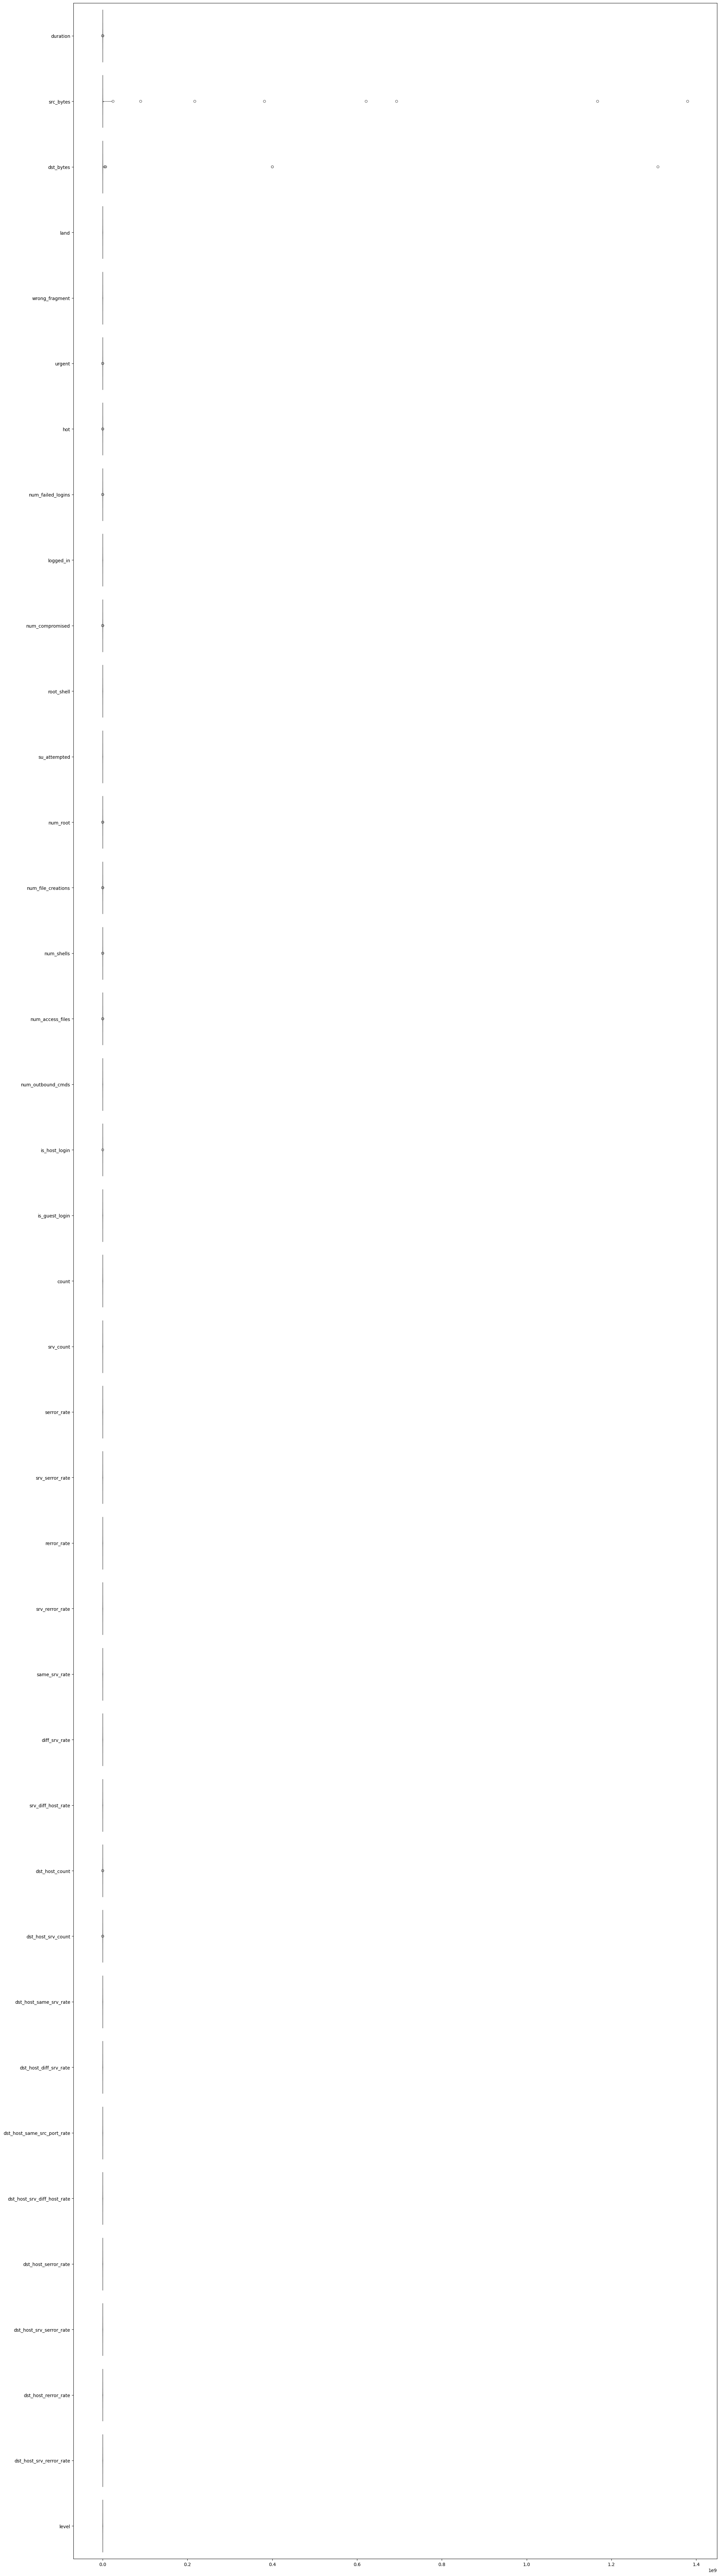

In [ ]:
plt.figure(figsize=(25,100))
sns.boxenplot(data=df_train,orient="h",)

In [ ]:
columns_to_drop = ['src_bytes','dst_bytes']
df_train = df_train.drop(columns=columns_to_drop)
df_test = df_test.drop(columns=columns_to_drop)

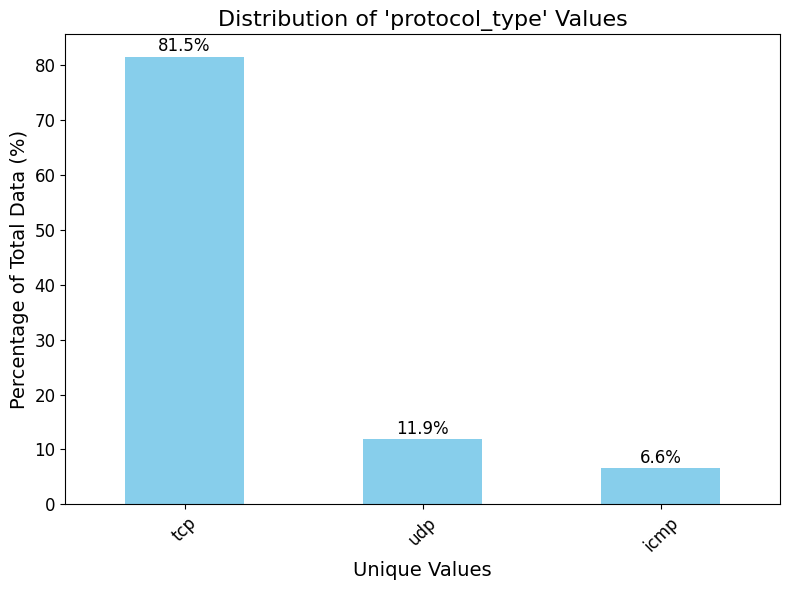

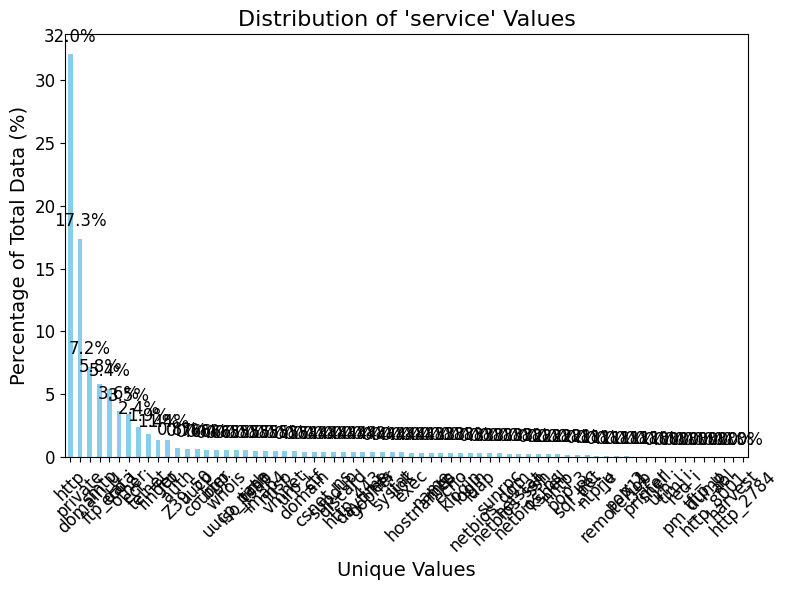

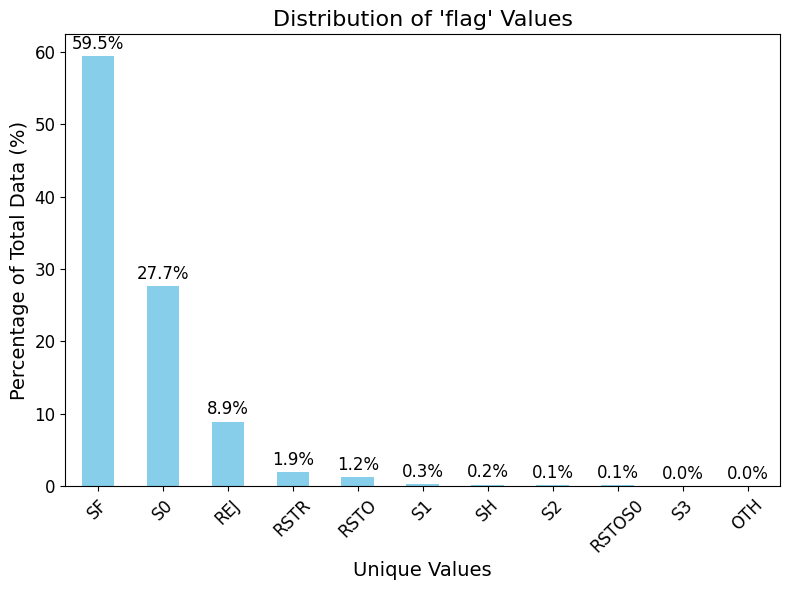

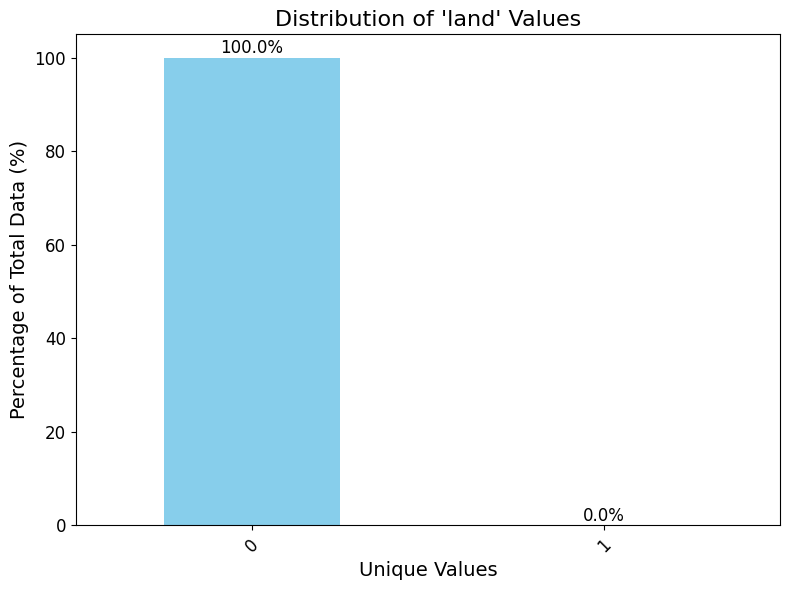

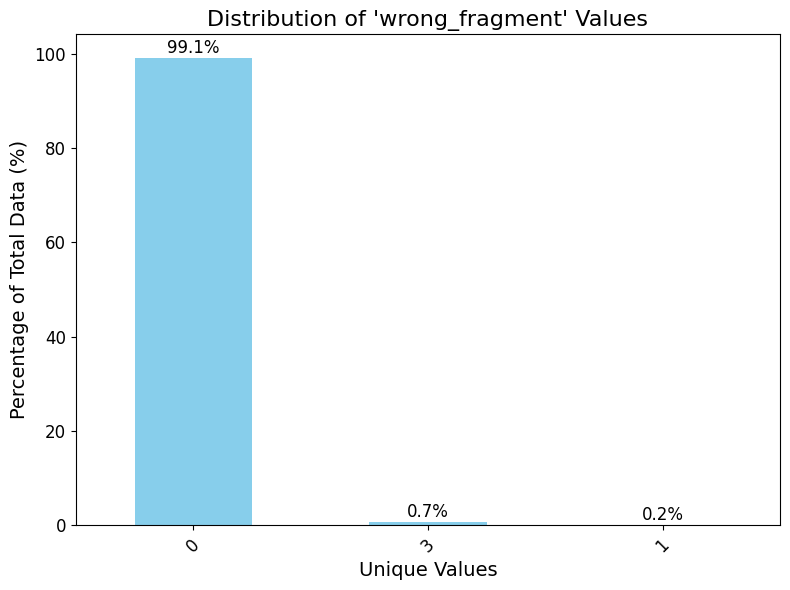

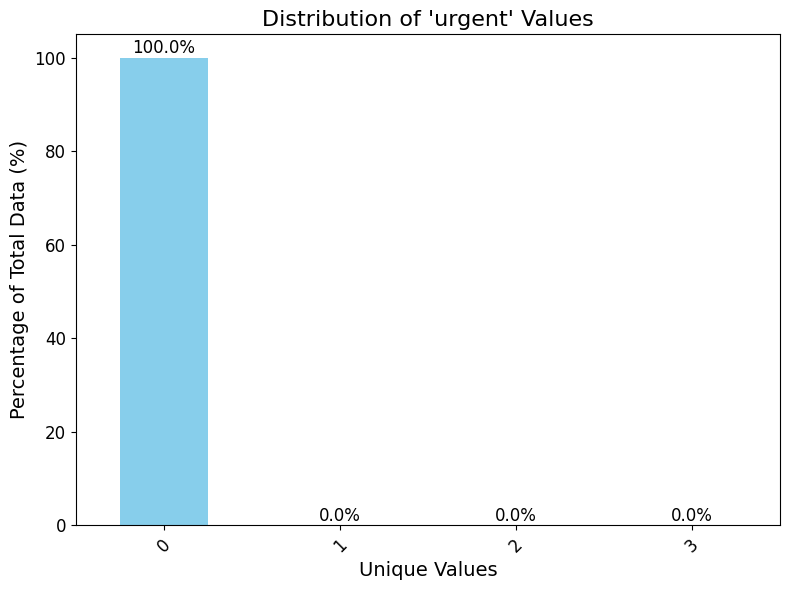

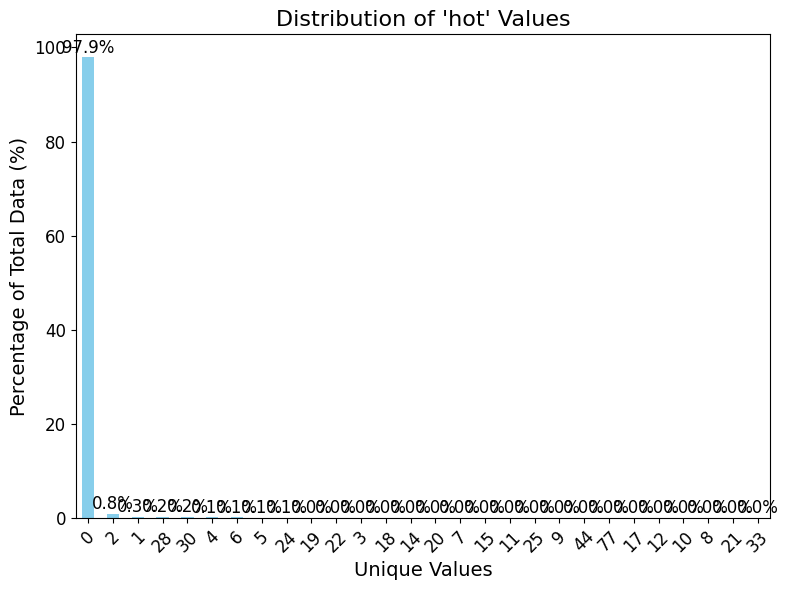

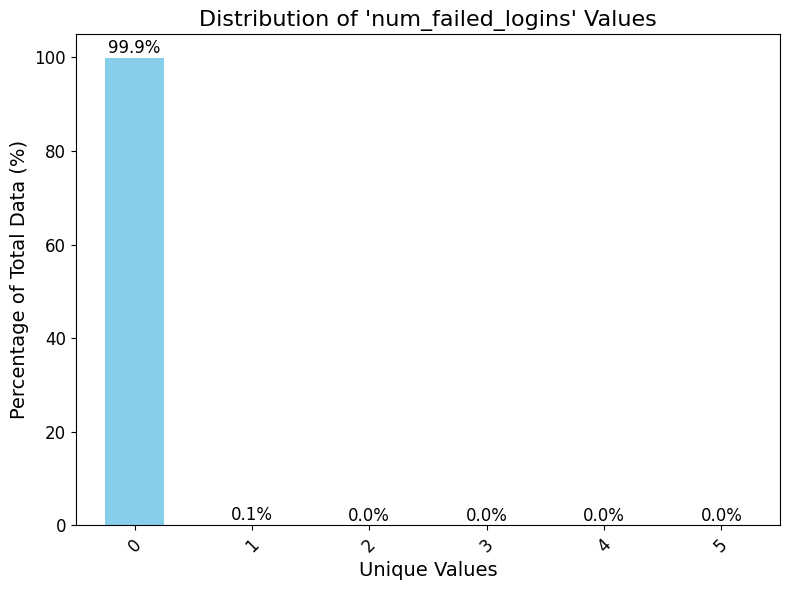

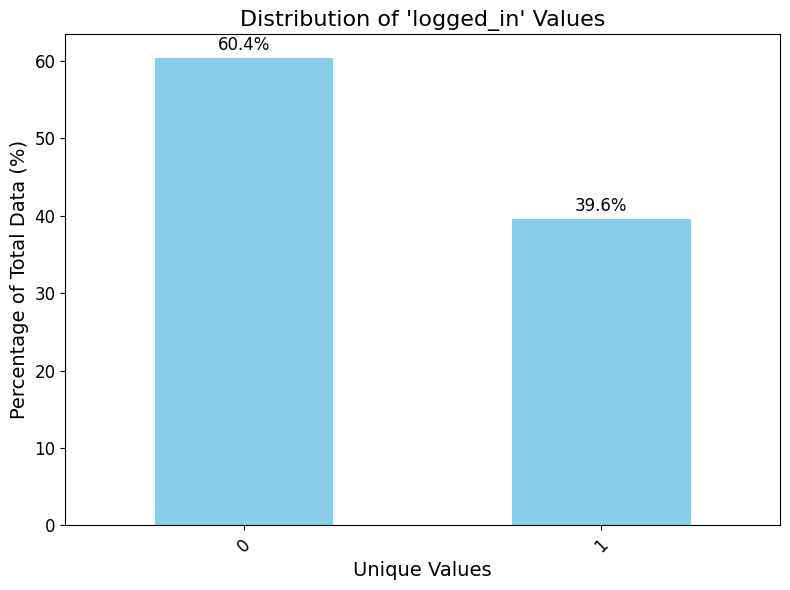

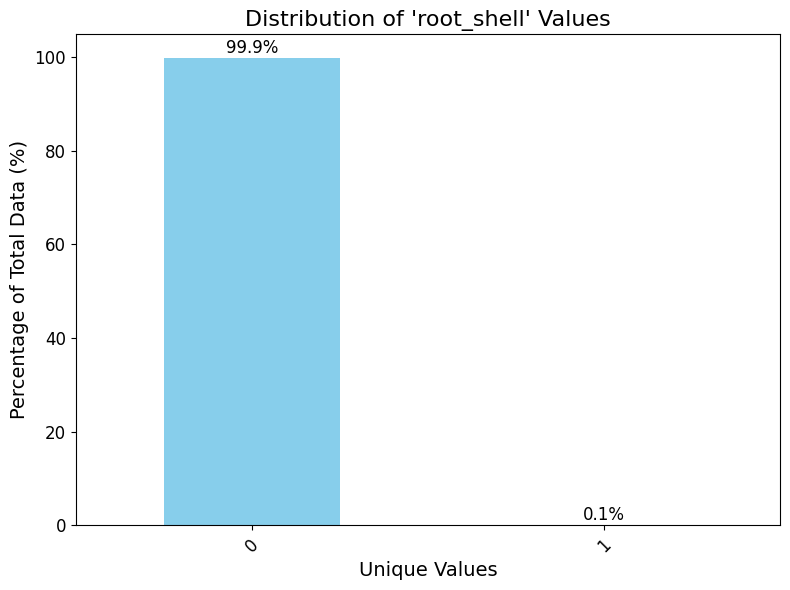

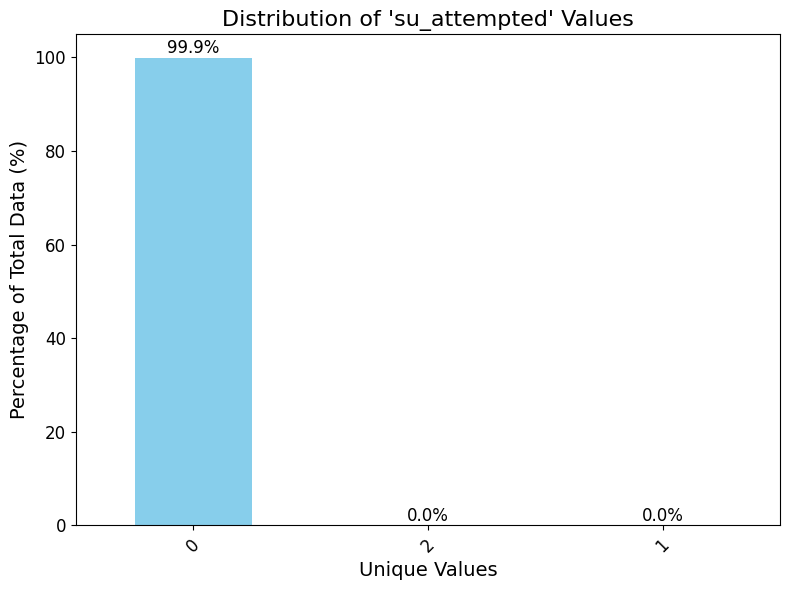

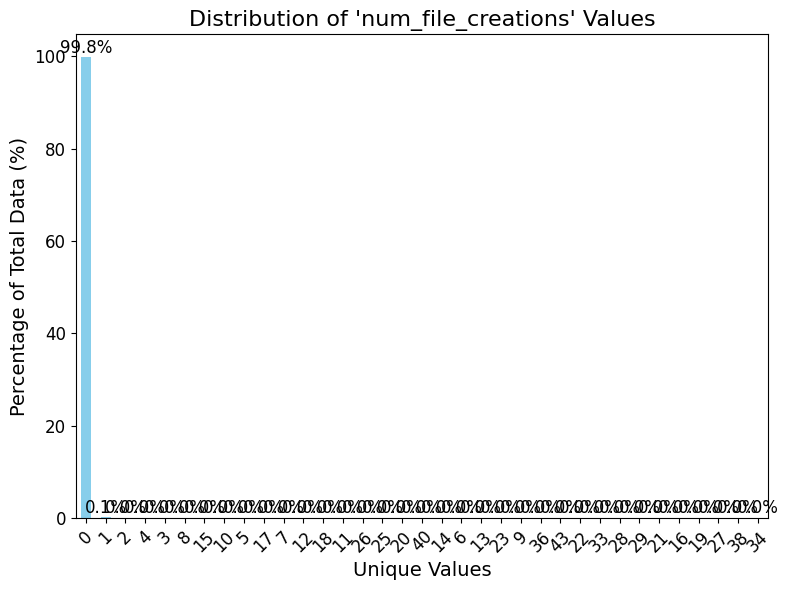

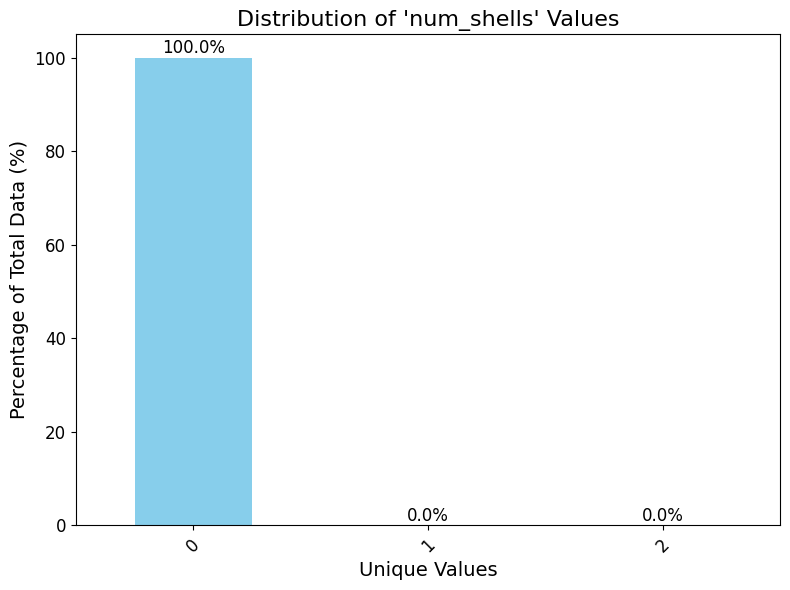

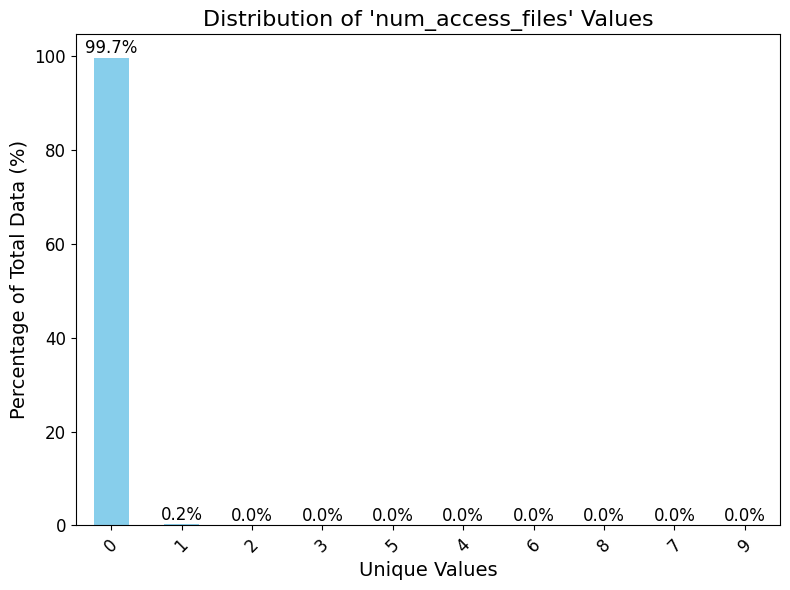

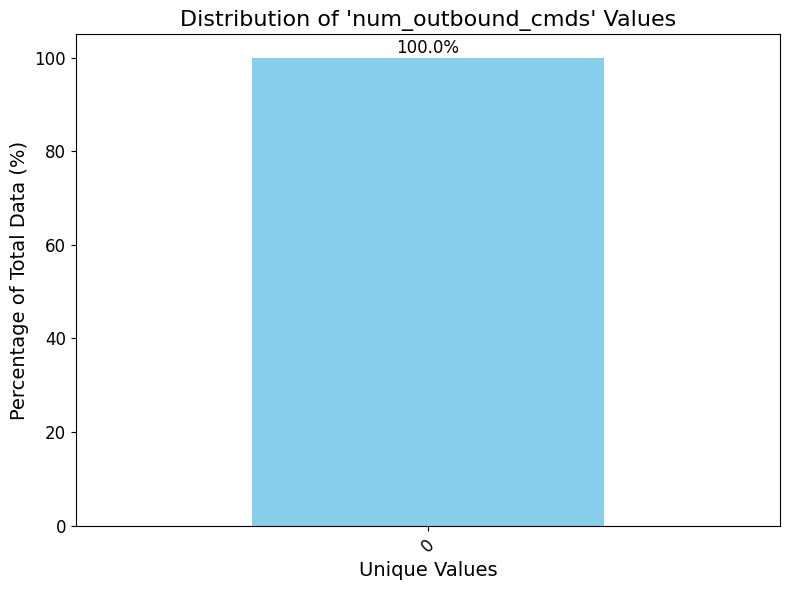

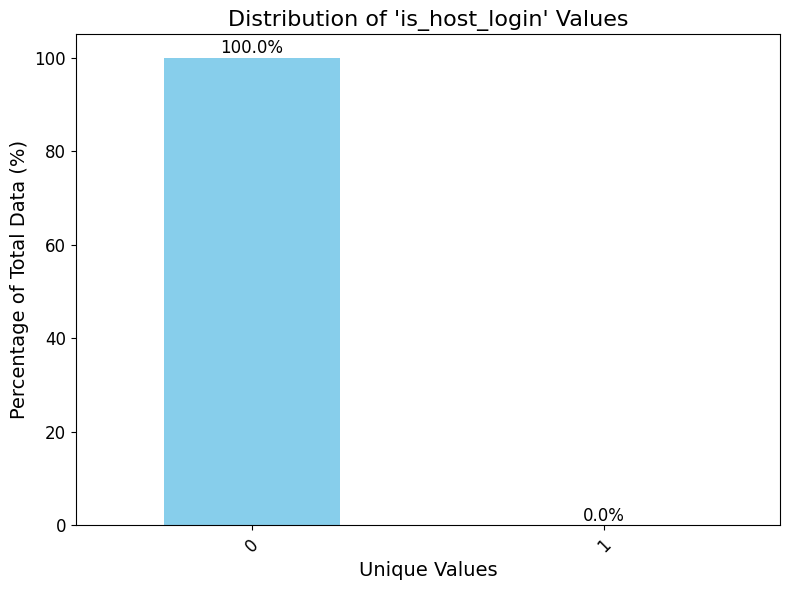

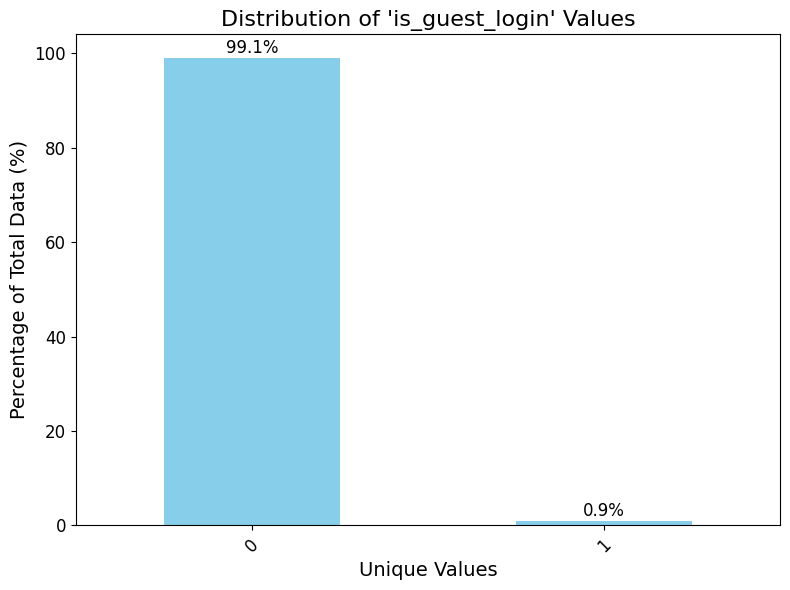

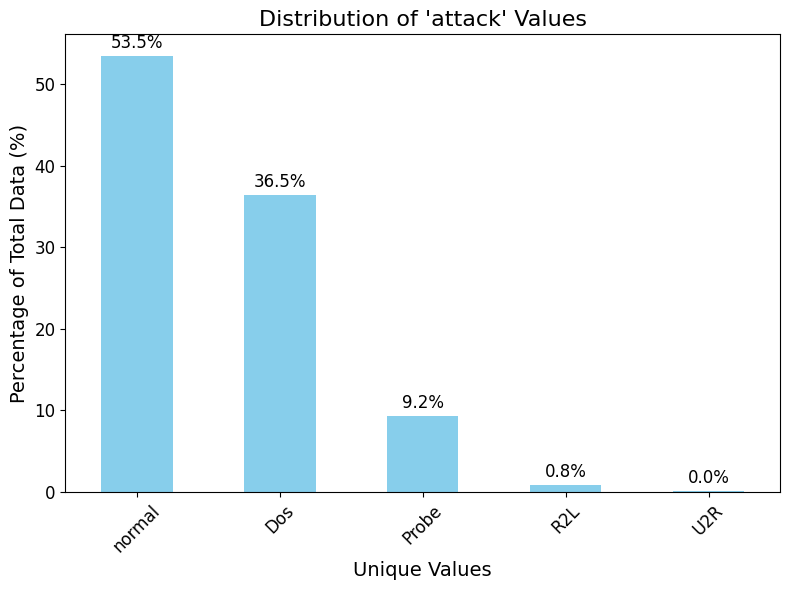

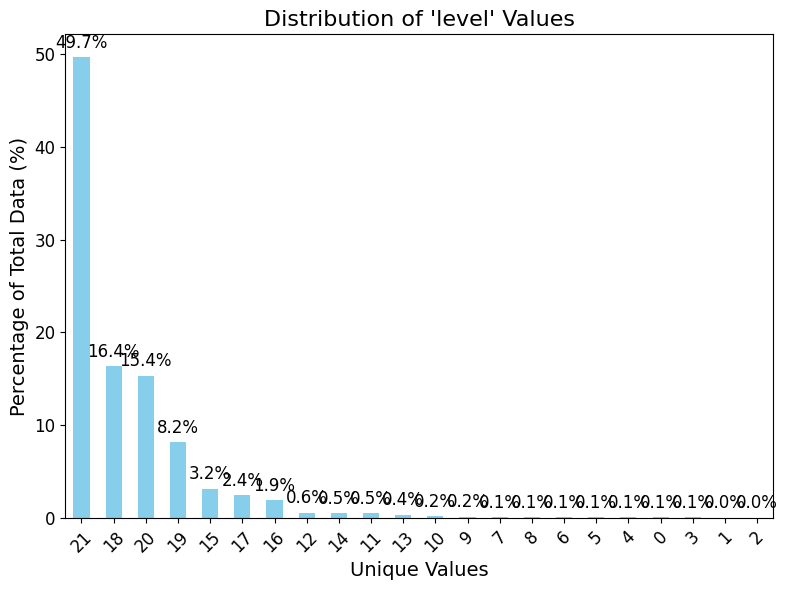

In [ ]:
data = df_train
for column in data.columns:
    if data[column].dtype == 'object' or data[column].nunique() < 50:
        value_counts = data[column].value_counts()
        total_count = len(data[column])
        percentages = (value_counts / total_count) * 100

        plt.figure(figsize=(8, 6))
        percentages.plot(kind='bar', color='skyblue')

        plt.title(f"Distribution of '{column}' Values", fontsize=16)
        plt.xlabel("Unique Values", fontsize=14)
        plt.ylabel("Percentage of Total Data (%)", fontsize=14)
        plt.xticks(rotation=45, fontsize=12)
        plt.yticks(fontsize=12)

        for index, value in enumerate(percentages):
            plt.text(index, value + 1, f"{value:.1f}%", ha='center', fontsize=12)

        plt.tight_layout()
        plt.show()

In [ ]:
cat_features = df_train.select_dtypes(include='object').columns
cat_features

Index(['protocol_type', 'service', 'flag', 'attack'], dtype='object')

In [ ]:
#label encoding
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
clm=['protocol_type', 'service', 'flag', 'attack']
df = [df_train,df_test]
for df in df:
    for x in clm:
        df[x]=le.fit_transform(df[x])


<Axes: >

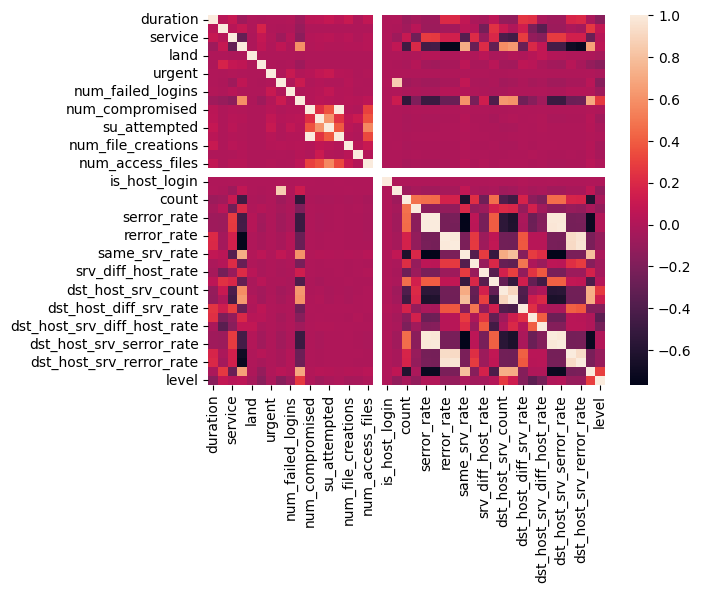

In [ ]:
correlation = df_train.corr()
sns.heatmap(correlation)

In [ ]:
import pandas as pd
import numpy as np

df = df_train.copy()

numeric_features = df.select_dtypes(include=[np.number]).drop(columns=['attack']).columns

cov_matrix = pd.DataFrame(index=numeric_features)

unique_classes = df['attack'].unique()
for class_label in unique_classes:
    binary_label = (df['attack'] == class_label).astype(int)
    cov_matrix[class_label] = [
        df[feature].cov(binary_label) for feature in numeric_features
    ]

top_features_per_class = {
    class_label: cov_matrix[class_label].abs().nlargest(10).index.tolist()
    for class_label in unique_classes
}

print("Top features per class:")
for class_label, features in top_features_per_class.items():
    print(f"Class {class_label}: {features}")

Top features per class:
Class 4: ['duration', 'dst_host_srv_count', 'count', 'dst_host_count', 'service', 'flag', 'level', 'logged_in', 'same_srv_rate', 'dst_host_same_srv_rate']
Class 0: ['duration', 'count', 'dst_host_srv_count', 'dst_host_count', 'service', 'srv_count', 'flag', 'same_srv_rate', 'dst_host_srv_serror_rate', 'srv_serror_rate']
Class 2: ['duration', 'dst_host_count', 'count', 'dst_host_srv_count', 'srv_count', 'level', 'service', 'hot', 'flag', 'logged_in']
Class 1: ['duration', 'dst_host_srv_count', 'dst_host_count', 'srv_count', 'count', 'service', 'level', 'flag', 'dst_host_same_src_port_rate', 'logged_in']
Class 3: ['duration', 'dst_host_count', 'dst_host_srv_count', 'count', 'srv_count', 'service', 'level', 'flag', 'hot', 'num_compromised']


In [ ]:
features_selected = set()
for key, value in top_features_per_class.items():
    features_selected.update(value)

In [ ]:
print(len(features_selected))
features_selected

16


{'count',
 'dst_host_count',
 'dst_host_same_src_port_rate',
 'dst_host_same_srv_rate',
 'dst_host_srv_count',
 'dst_host_srv_serror_rate',
 'duration',
 'flag',
 'hot',
 'level',
 'logged_in',
 'num_compromised',
 'same_srv_rate',
 'service',
 'srv_count',
 'srv_serror_rate'}

In [ ]:
columns_to_keep = list(features_selected)
columns_to_keep.append('attack')

df_test = df_test.loc[:, columns_to_keep]
df_train = df_train.loc[:, columns_to_keep]
print(df_test.shape)
print(df_train.shape)

(22540, 17)
(125963, 17)


In [ ]:
X_train = df_train.drop(['attack'], axis=1)
X_test = df_test.drop(['attack'], axis=1)
y_train = df_train['attack']
y_test = df_test['attack']

In [ ]:
df_test.head()

,flag,same_srv_rate,srv_count,srv_serror_rate,dst_host_srv_count,service,level,hot,duration,dst_host_same_src_port_rate,dst_host_same_srv_rate,num_compromised,dst_host_srv_serror_rate,logged_in,count,dst_host_count,attack
0,1,0.01,1,0.00,1,45,21,0,0,0.00,0.00,0,0.0,0,136,255,0
1,9,1.00,1,0.00,86,19,21,0,2,0.61,0.61,0,0.0,0,1,134,4
2,9,1.00,65,0.00,57,13,15,0,0,1.00,1.00,0,0.0,0,1,3,1
3,2,1.00,8,0.12,86,55,11,0,1,0.03,0.31,0,0.0,0,1,29,1
4,9,1.00,4,0.00,255,22,21,0,0,0.01,1.00,0,0.0,1,4,155,4


In [ ]:
df_train.head()

,flag,same_srv_rate,srv_count,srv_serror_rate,dst_host_srv_count,service,level,hot,duration,dst_host_same_src_port_rate,dst_host_same_srv_rate,num_compromised,dst_host_srv_serror_rate,logged_in,count,dst_host_count,attack
0,9,0.08,1,0.0,1,44,15,0,0,0.88,0.00,0,0.00,0,13,255,4
1,5,0.05,6,1.0,26,49,19,0,0,0.00,0.10,0,1.00,0,123,255,0
2,9,1.00,5,0.2,255,24,21,0,0,0.03,1.00,0,0.01,1,5,30,4
3,9,1.00,32,0.0,255,24,21,0,0,0.00,1.00,0,0.00,1,30,255,4
4,1,0.16,19,0.0,19,49,21,0,0,0.00,0.07,0,0.00,0,121,255,0


# Knn

n_neighbors: 1 - Accuracy: 0.7260
n_neighbors: 2 - Accuracy: 0.7282
n_neighbors: 3 - Accuracy: 0.7240
n_neighbors: 4 - Accuracy: 0.7269
n_neighbors: 5 - Accuracy: 0.7240
n_neighbors: 6 - Accuracy: 0.7256
n_neighbors: 7 - Accuracy: 0.7213
n_neighbors: 8 - Accuracy: 0.7229
n_neighbors: 9 - Accuracy: 0.7188
n_neighbors: 10 - Accuracy: 0.7201
n_neighbors: 11 - Accuracy: 0.7165
n_neighbors: 12 - Accuracy: 0.7167
n_neighbors: 13 - Accuracy: 0.7127
n_neighbors: 14 - Accuracy: 0.7142
n_neighbors: 15 - Accuracy: 0.7124
n_neighbors: 16 - Accuracy: 0.7137
n_neighbors: 17 - Accuracy: 0.7115
n_neighbors: 18 - Accuracy: 0.7128
n_neighbors: 19 - Accuracy: 0.7110
n_neighbors: 20 - Accuracy: 0.7118
n_neighbors: 21 - Accuracy: 0.7094
n_neighbors: 22 - Accuracy: 0.7019
n_neighbors: 23 - Accuracy: 0.6995
n_neighbors: 24 - Accuracy: 0.6981


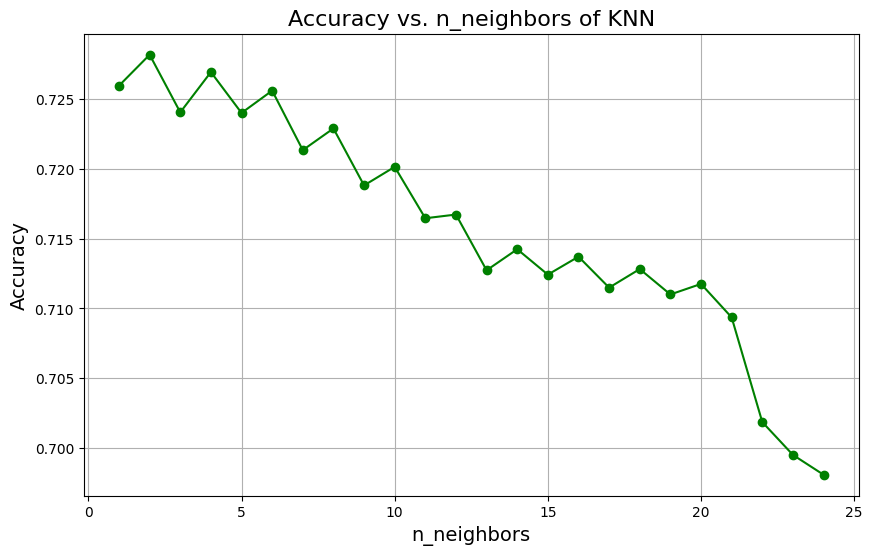

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define the range of n_neighbors values to explore
n_neighbors_range = range(1, 25)  # Try values from 1 to 20
accuracies = []

for n_neighbors in n_neighbors_range:
  # Create a KNN classifier with the current n_neighbors value
  knn = KNeighborsClassifier(n_neighbors=n_neighbors)
  # Train the classifier
  knn.fit(X_train, y_train)
  # Make predictions on the test set
  y_pred = knn.predict(X_test)
  # Calculate accuracy and store it
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print(f"n_neighbors: {n_neighbors} - Accuracy: {accuracy:.4f}")

# Plot the accuracy vs. n_neighbors
plt.figure(figsize=(10, 6))
plt.plot(n_neighbors_range, accuracies, marker='o', color='g')
plt.title('Accuracy vs. n_neighbors of KNN', fontsize=16) # Changed title
plt.xlabel('n_neighbors', fontsize=14) # Changed x-axis label
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True)
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.70      0.77      7459
           1       0.62      0.51      0.56      2418
           2       0.88      0.06      0.11      2885
           3       1.00      0.01      0.03        67
           4       0.64      0.94      0.76      9711

    accuracy                           0.70     22540
   macro avg       0.80      0.44      0.45     22540
weighted avg       0.74      0.70      0.66     22540



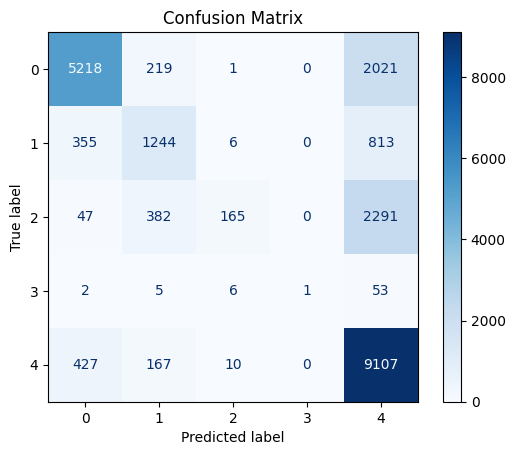

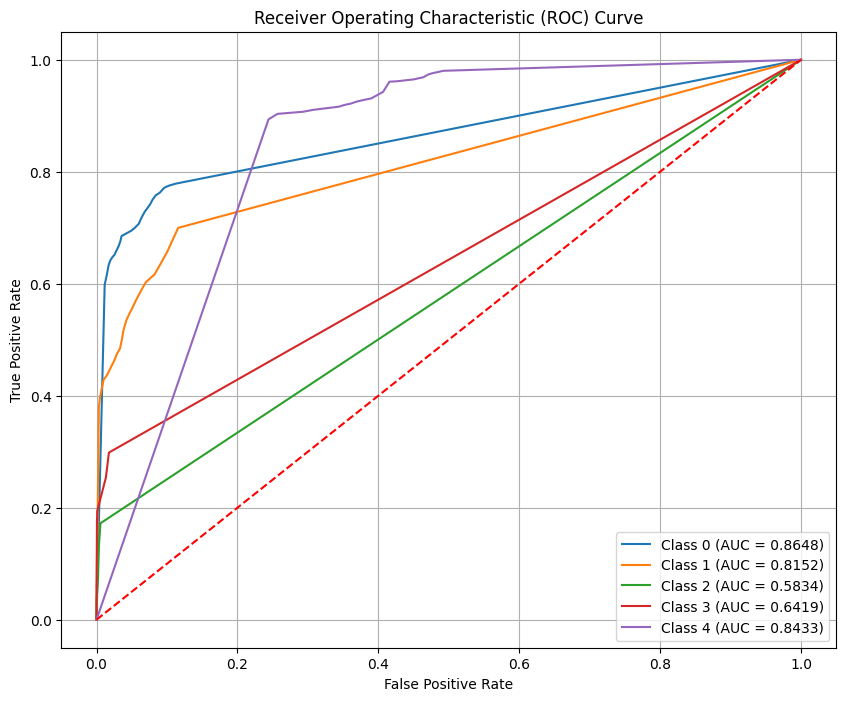

Training Accuracy: 0.9780
Validation Accuracy: 0.6981
Precision (Weighted): 0.7416
Recall (Weighted): 0.6981
F1-Score (Weighted): 0.6567
Training Loss: 0.0491
Validation Loss: 8.1610
AUC-ROC (Weighted): 0.8135


In [ ]:
model = knn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)
from sklearn.preprocessing import label_binarize

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)
y_val_proba = model.predict_proba(X_test)

# Metrics for Accuracy and Loss
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_test, y_val_proba)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_val_pred))

# F1 Score (weighted to handle multiclass)
f1 = f1_score(y_test, y_val_pred, average="weighted")

# Precision and Recall (weighted to handle multiclass)
precision = precision_score(y_test, y_val_pred, average="weighted")
recall = recall_score(y_test, y_val_pred, average="weighted")

# AUC-ROC (one-vs-rest approach)
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
auc_roc = roc_auc_score(y_test_bin, y_val_proba, multi_class="ovr", average="weighted")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (per class)
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_val_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc_score(y_test_bin[:, i], y_val_proba[:, i]):.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Print Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"AUC-ROC (Weighted): {auc_roc:.4f}")

In [ ]:
model = LogisticRegression(max_iter=30, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6109139307897072


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.94
Validation Accuracy: 0.70
Precision: 0.71
Recall: 0.70
F1 Score: 0.66
Training Loss: 0.30
Validation Loss: 0.40


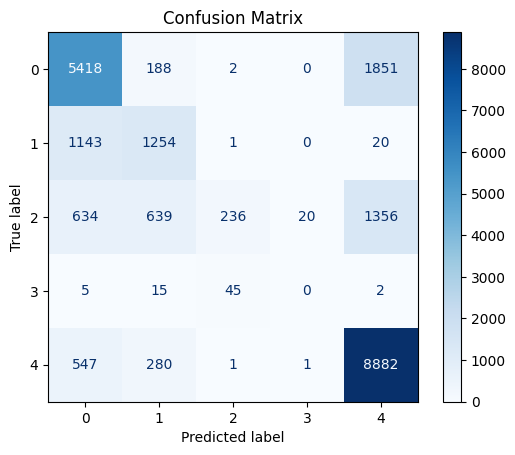

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score)
import numpy as np

# Fit the Logistic Regression model
model = LogisticRegression(max_iter=30, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]  # Predicted probabilities for ROC curve (binary classification)

# Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

# Placeholder losses (replace with actual values if available)
train_loss = 0.3  # Example value
val_loss = 0.4    # Example value

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {test_accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Training Loss: {train_loss:.2f}")
print(f"Validation Loss: {val_loss:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()




In [ ]:
# ROC Curve (for binary classification)
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic")
    plt.legend(loc="lower right")
    plt.show()

Explained variance ratio by each component:
[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]

Cumulative explained variance ratio:
[0.09090909 0.18181818 0.27272727 0.36363636 0.45454545 0.54545455
 0.63636364 0.72727273 0.81818182 0.90909091 1.        ]

Number of components selected: 11


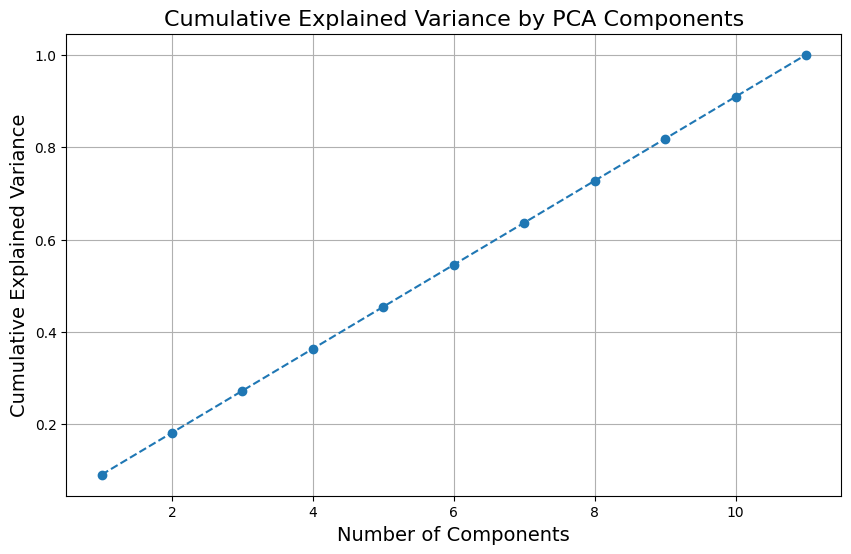

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

# Display results
print("Explained variance ratio by each component:")
print(explained_variance_ratio)
print("\nCumulative explained variance ratio:")
print(cumulative_variance)

print(f"\nNumber of components selected: {pca.n_components_}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components', fontsize=16)
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Cumulative Explained Variance', fontsize=14)
plt.grid(True)
plt.show()

X_test = X_test_pca
X_train = X_train_pca

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      7459
           1       0.57      0.67      0.61      2418
           2       0.57      0.01      0.02      2885
           3       0.92      0.18      0.30        67
           4       0.75      0.97      0.85      9711

    accuracy                           0.76     22540
   macro avg       0.73      0.53      0.52     22540
weighted avg       0.74      0.76      0.71     22540



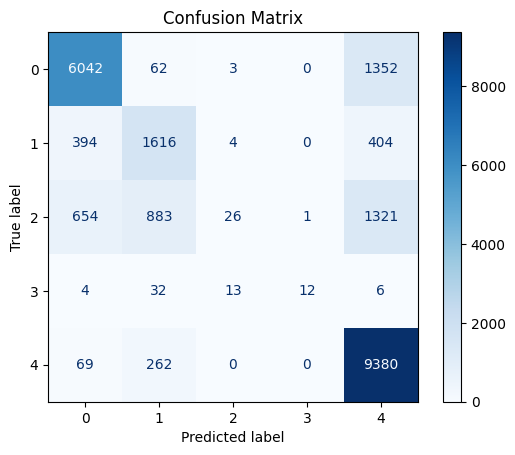

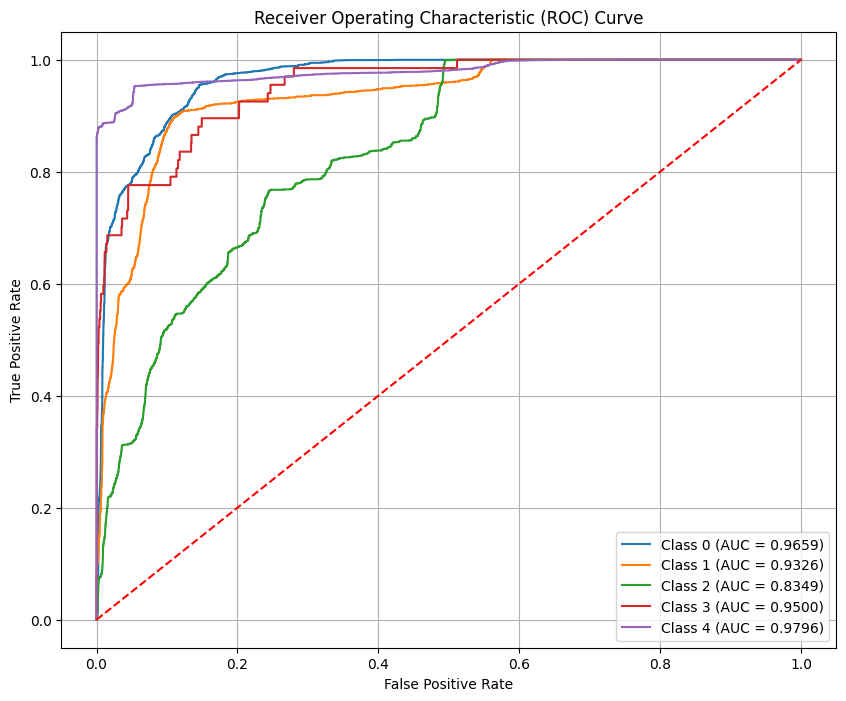

Training Accuracy: 0.9893
Validation Accuracy: 0.7576
Precision (Weighted): 0.7392
Recall (Weighted): 0.7576
F1-Score (Weighted): 0.7069
Training Loss: 0.0318
Validation Loss: 1.2343
AUC-ROC (Weighted): 0.9514


# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
n_estimators = 2
rf = RandomForestClassifier(n_estimators=2, random_state=93)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(n_estimators, "-",accuracy)

2 - 0.7775953859804792


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      7459
           1       0.58      0.74      0.65      2418
           2       0.66      0.08      0.14      2885
           3       0.05      0.03      0.04        67
           4       0.80      0.95      0.87      9711

    accuracy                           0.78     22540
   macro avg       0.58      0.53      0.51     22540
weighted avg       0.77      0.78      0.74     22540



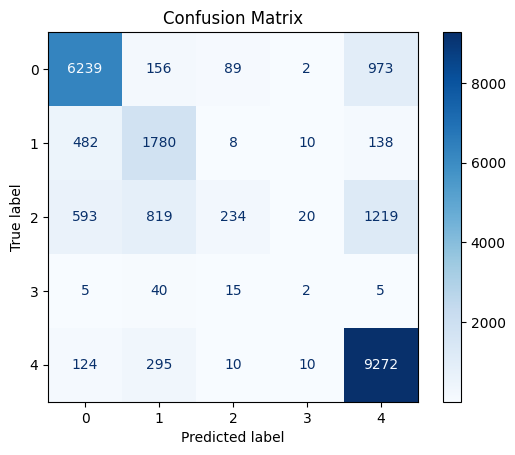

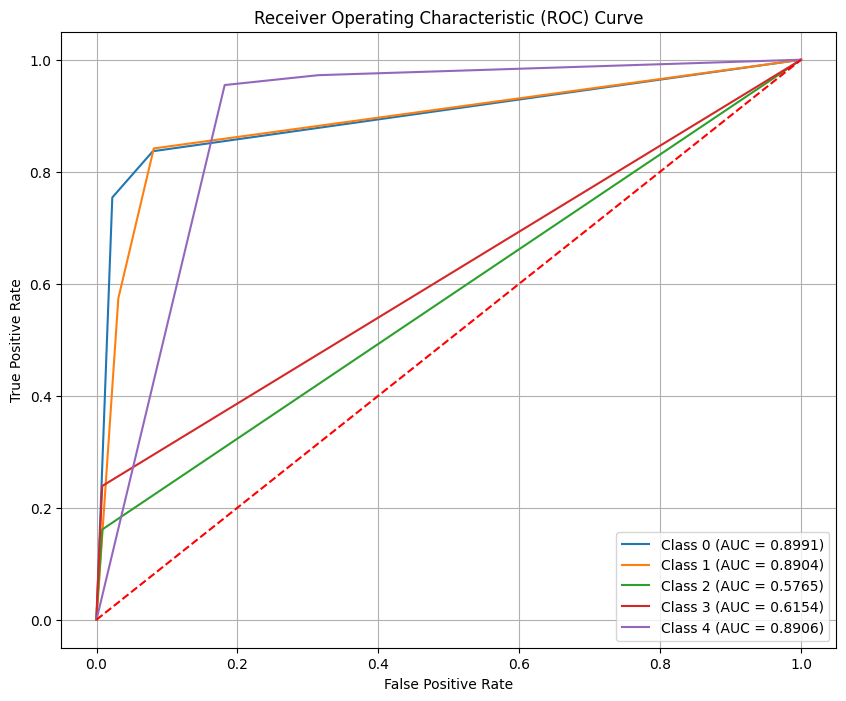

Training Accuracy: 0.9975
Validation Accuracy: 0.7776
Precision (Weighted): 0.7676
Recall (Weighted): 0.7776
F1-Score (Weighted): 0.7398
Training Loss: 0.0106
Validation Loss: 6.9989
AUC-ROC (Weighted): 0.8524


In [ ]:
model = rf
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)
from sklearn.preprocessing import label_binarize

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)
y_val_proba = model.predict_proba(X_test)

# Metrics for Accuracy and Loss
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_test, y_val_proba)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_val_pred))

# F1 Score (weighted to handle multiclass)
f1 = f1_score(y_test, y_val_pred, average="weighted")

# Precision and Recall (weighted to handle multiclass)
precision = precision_score(y_test, y_val_pred, average="weighted")
recall = recall_score(y_test, y_val_pred, average="weighted")

# AUC-ROC (one-vs-rest approach)
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
auc_roc = roc_auc_score(y_test_bin, y_val_proba, multi_class="ovr", average="weighted")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (per class)
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_val_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc_score(y_test_bin[:, i], y_val_proba[:, i]):.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Print Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"AUC-ROC (Weighted): {auc_roc:.4f}")

# Decision Tree

Max Depth: 1 - Accuracy: 0.6323
Max Depth: 2 - Accuracy: 0.6376
Max Depth: 3 - Accuracy: 0.7016
Max Depth: 4 - Accuracy: 0.7717
Max Depth: 5 - Accuracy: 0.7546
Max Depth: 6 - Accuracy: 0.7492
Max Depth: 7 - Accuracy: 0.7745
Max Depth: 8 - Accuracy: 0.7566
Max Depth: 9 - Accuracy: 0.7730
Max Depth: 10 - Accuracy: 0.7677
Max Depth: 11 - Accuracy: 0.7614
Max Depth: 12 - Accuracy: 0.7717
Max Depth: 13 - Accuracy: 0.7572
Max Depth: 14 - Accuracy: 0.7739
Max Depth: 15 - Accuracy: 0.7728
Max Depth: 16 - Accuracy: 0.7744
Max Depth: 17 - Accuracy: 0.7541
Max Depth: 18 - Accuracy: 0.7447
Max Depth: 19 - Accuracy: 0.7565
Max Depth: 20 - Accuracy: 0.7668
Max Depth: 21 - Accuracy: 0.7663
Max Depth: 22 - Accuracy: 0.7650
Max Depth: 23 - Accuracy: 0.7650
Max Depth: 24 - Accuracy: 0.7647
Max Depth: 25 - Accuracy: 0.7649
Max Depth: 26 - Accuracy: 0.7649
Max Depth: 27 - Accuracy: 0.7649
Max Depth: 28 - Accuracy: 0.7649
Max Depth: 29 - Accuracy: 0.7649
Max Depth: 30 - Accuracy: 0.7649
Max Depth: 31 - Acc

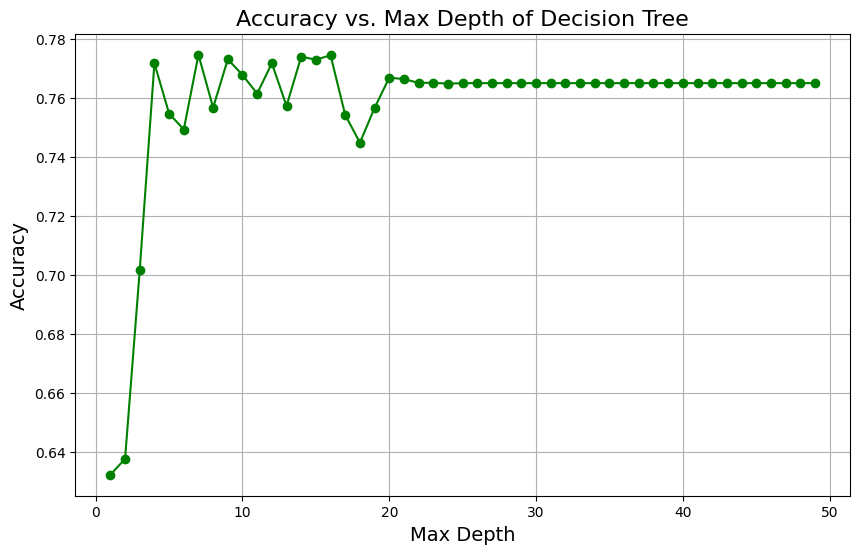

The optimal max depth is: 7


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

max_depth_range = range(1, 50)
accuracies = []

for max_depth in max_depth_range:
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"Max Depth: {max_depth} - Accuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, accuracies, marker='o', color='g')
plt.title('Accuracy vs. Max Depth of Decision Tree', fontsize=16)
plt.xlabel('Max Depth', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True)
plt.show()


optimal_max_depth = max_depth_range[accuracies.index(max(accuracies))]
print(f"The optimal max depth is: {optimal_max_depth}")

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      7459
           1       0.62      0.64      0.63      2418
           2       0.90      0.09      0.16      2885
           3       0.24      0.18      0.21        67
           4       0.74      0.97      0.84      9711

    accuracy                           0.76     22540
   macro avg       0.67      0.54      0.53     22540
weighted avg       0.79      0.76      0.73     22540



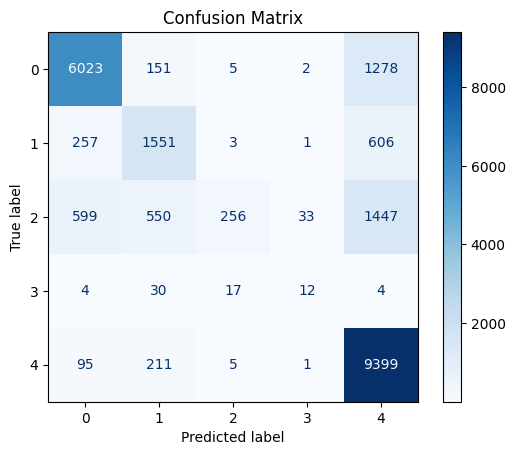

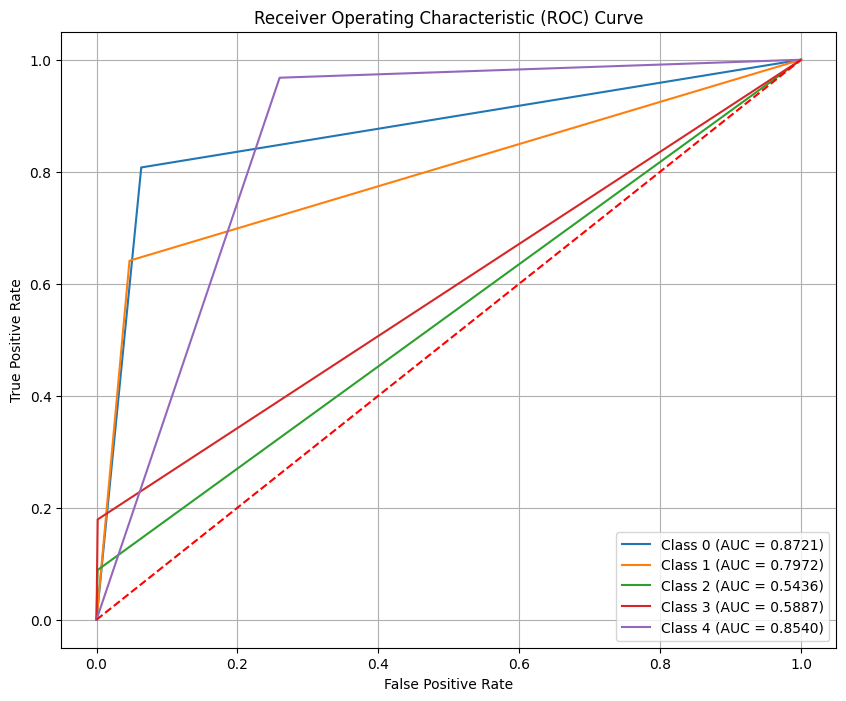

Training Accuracy: 0.9999
Validation Accuracy: 0.7649
Precision (Weighted): 0.7857
Recall (Weighted): 0.7649
F1-Score (Weighted): 0.7260
Training Loss: 0.0001
Validation Loss: 8.4726
AUC-ROC (Weighted): 0.8134


In [ ]:
model = dt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)
from sklearn.preprocessing import label_binarize

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)
y_val_proba = model.predict_proba(X_test)

# Metrics for Accuracy and Loss
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_test, y_val_proba)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_val_pred))

# F1 Score (weighted to handle multiclass)
f1 = f1_score(y_test, y_val_pred, average="weighted")

# Precision and Recall (weighted to handle multiclass)
precision = precision_score(y_test, y_val_pred, average="weighted")
recall = recall_score(y_test, y_val_pred, average="weighted")

# AUC-ROC (one-vs-rest approach)
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
auc_roc = roc_auc_score(y_test_bin, y_val_proba, multi_class="ovr", average="weighted")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (per class)
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_val_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc_score(y_test_bin[:, i], y_val_proba[:, i]):.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Print Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"AUC-ROC (Weighted): {auc_roc:.4f}")

# SVM

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      7459
           1       0.56      0.65      0.60      2418
           2       0.44      0.01      0.01      2885
           3       0.90      0.13      0.23        67
           4       0.73      0.97      0.83      9711

    accuracy                           0.76     22540
   macro avg       0.71      0.52      0.51     22540
weighted avg       0.73      0.76      0.71     22540



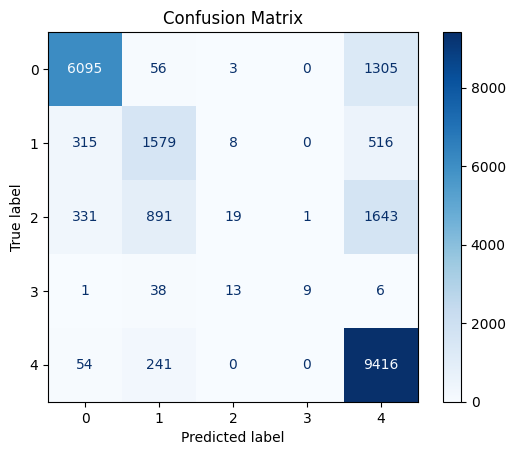

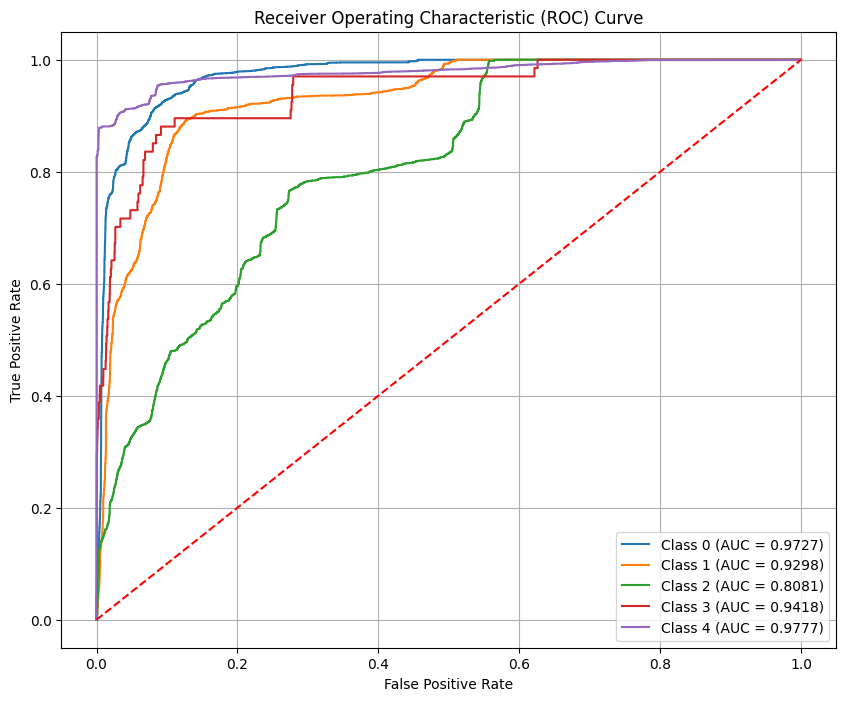

Training Accuracy: 0.9905
Validation Accuracy: 0.7594
Precision (Weighted): 0.7312
Recall (Weighted): 0.7594
F1-Score (Weighted): 0.7093
Training Loss: 0.0278
Validation Loss: 1.2606
AUC-ROC (Weighted): 0.9491


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Train the SVM model
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm.fit(X_train_pca, y_train)

# Predictions and probabilities
y_train_pred = svm.predict(X_train_pca)
y_val_pred = svm.predict(X_test_pca)
y_train_proba = svm.predict_proba(X_train_pca)
y_val_proba = svm.predict_proba(X_test_pca)

# Metrics for Accuracy and Loss
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)
train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_test, y_val_proba)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_val_pred))

# F1 Score (weighted to handle multiclass)
f1 = f1_score(y_test, y_val_pred, average="weighted")

# Precision and Recall (weighted to handle multiclass)
precision = precision_score(y_test, y_val_pred, average="weighted")
recall = recall_score(y_test, y_val_pred, average="weighted")

# AUC-ROC (one-vs-rest approach)
classes = svm.classes_
y_test_bin = label_binarize(y_test, classes=classes)
auc_roc = roc_auc_score(y_test_bin, y_val_proba, multi_class="ovr", average="weighted")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (per class)
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_val_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc_score(y_test_bin[:, i], y_val_proba[:, i]):.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Print Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"AUC-ROC (Weighted): {auc_roc:.4f}")


# Naive-Bayes

Accuracy: 0.6953416149068323


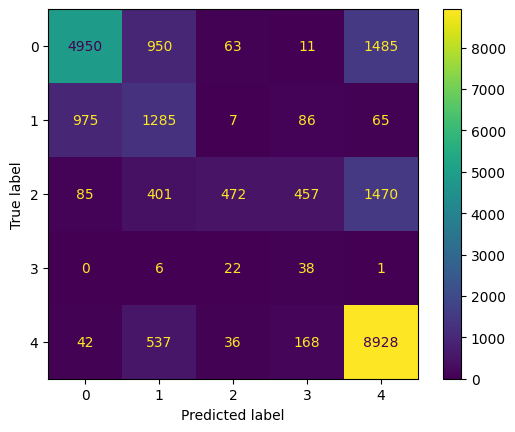

In [ ]:


from sklearn.naive_bayes import GaussianNB

# Initialize and train the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred = nb_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.66      0.73      7459
           1       0.40      0.53      0.46      2418
           2       0.79      0.16      0.27      2885
           3       0.05      0.57      0.09        67
           4       0.75      0.92      0.82      9711

    accuracy                           0.70     22540
   macro avg       0.56      0.57      0.48     22540
weighted avg       0.74      0.70      0.68     22540



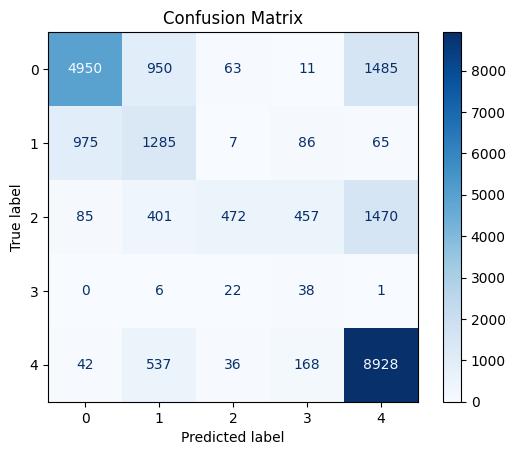

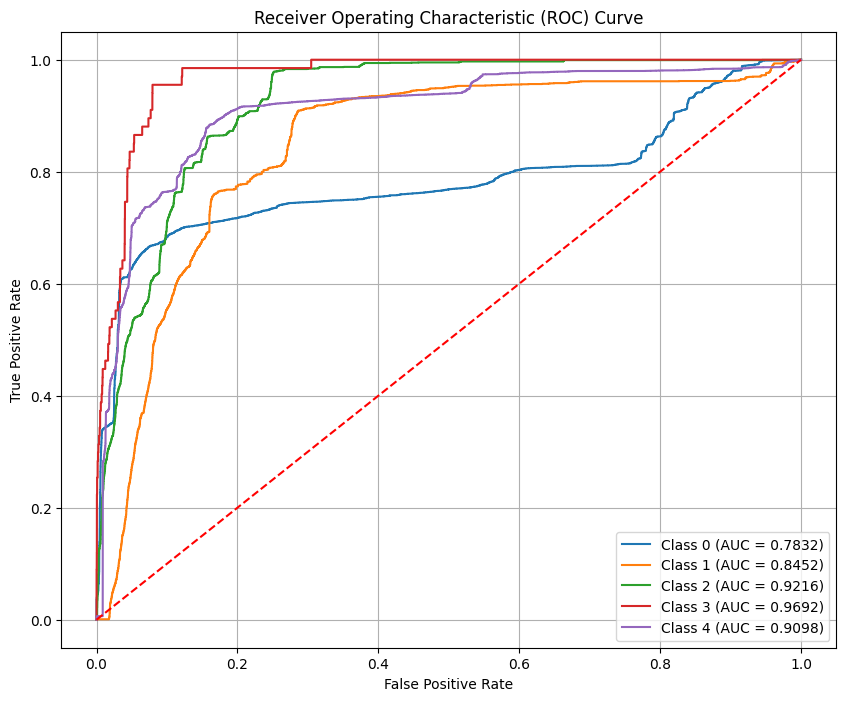

Training Accuracy: 0.8857
Validation Accuracy: 0.6953
Precision (Weighted): 0.7368
Recall (Weighted): 0.6953
F1-Score (Weighted): 0.6819
Training Loss: 0.7257
Validation Loss: 2.7771
AUC-ROC (Weighted): 0.8627


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Initialize and fit the Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)
y_val_proba = model.predict_proba(X_test)

# Metrics for Accuracy and Loss
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

# For Naive Bayes, we can compute log_loss (but it may be NaN for certain cases, depending on predicted probabilities)
try:
    train_loss = log_loss(y_train, y_train_proba)
    val_loss = log_loss(y_test, y_val_proba)
except ValueError:
    train_loss = val_loss = float('nan')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_val_pred))

# F1 Score (weighted to handle multiclass)
f1 = f1_score(y_test, y_val_pred, average="weighted")

# Precision and Recall (weighted to handle multiclass)
precision = precision_score(y_test, y_val_pred, average="weighted")
recall = recall_score(y_test, y_val_pred, average="weighted")

# AUC-ROC (one-vs-rest approach)
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
auc_roc = roc_auc_score(y_test_bin, y_val_proba, multi_class="ovr", average="weighted")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (per class)
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_val_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc_score(y_test_bin[:, i], y_val_proba[:, i]):.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Print Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"AUC-ROC (Weighted): {auc_roc:.4f}")


# Stacked Ensemble





In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

base_models = [
    # ('random_forest', RandomForestClassifier(n_estimators=2, random_state=42)),
    ('decision_tree', DecisionTreeClassifier(max_depth=6, random_state=42)),
    # ('naive_bayes', GaussianNB())
    ('SVC', SVC(random_state=42))
]

meta_model = LogisticRegression(random_state=42, max_iter=1000)
# meta_model = SVC(random_state=42)

stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=3, n_jobs=-1)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Stacking Ensemble Accuracy: {accuracy:.4f}\n")

Stacking Ensemble Accuracy: 0.7396



Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      7459
           1       0.49      0.53      0.51      2418
           2       0.63      0.01      0.02      2885
           3       0.87      0.19      0.32        67
           4       0.75      0.97      0.85      9711

    accuracy                           0.74     22540
   macro avg       0.71      0.50      0.50     22540
weighted avg       0.73      0.74      0.69     22540



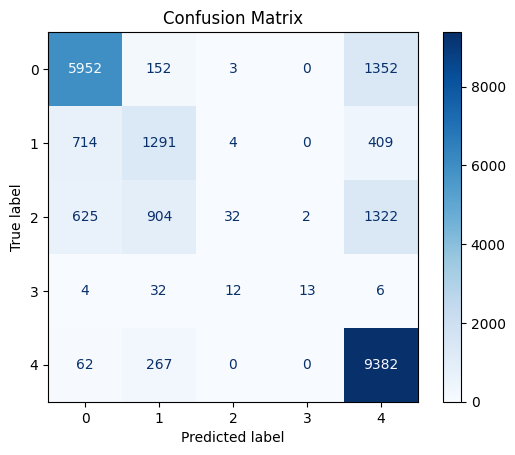

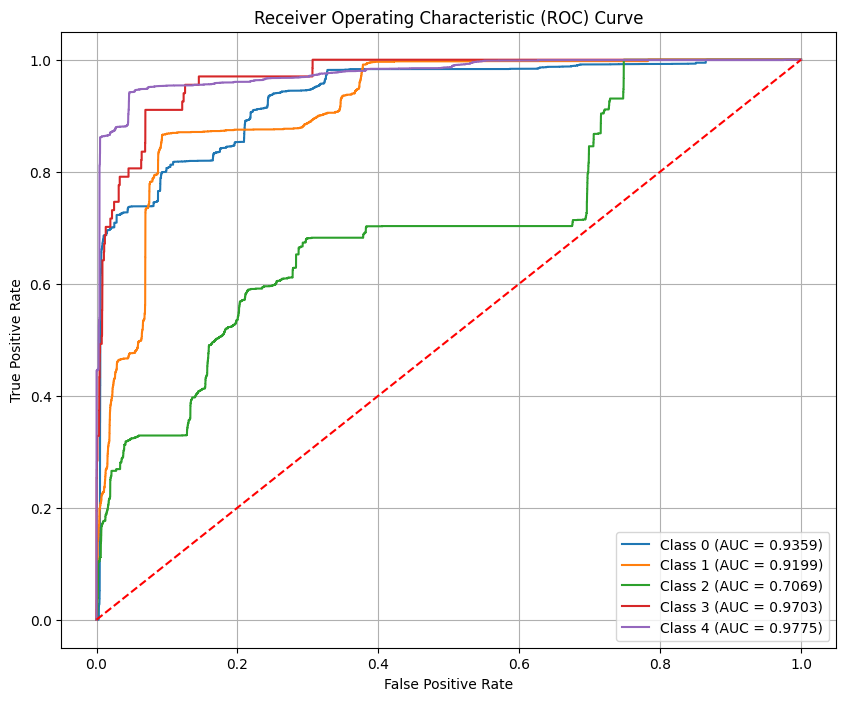

Training Accuracy: 0.9901
Validation Accuracy: 0.7396
Precision (Weighted): 0.7271
Recall (Weighted): 0.7396
F1-Score (Weighted): 0.6888
Training Loss: 0.0405
Validation Loss: 1.5953
AUC-ROC (Weighted): 0.9229


In [ ]:
model = stacking_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)
from sklearn.preprocessing import label_binarize

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)
y_val_proba = model.predict_proba(X_test)

# Metrics for Accuracy and Loss
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_test, y_val_proba)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_val_pred))

# F1 Score (weighted to handle multiclass)
f1 = f1_score(y_test, y_val_pred, average="weighted")

# Precision and Recall (weighted to handle multiclass)
precision = precision_score(y_test, y_val_pred, average="weighted")
recall = recall_score(y_test, y_val_pred, average="weighted")

# AUC-ROC (one-vs-rest approach)
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
auc_roc = roc_auc_score(y_test_bin, y_val_proba, multi_class="ovr", average="weighted")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (per class)
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_val_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc_score(y_test_bin[:, i], y_val_proba[:, i]):.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Print Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"AUC-ROC (Weighted): {auc_roc:.4f}")